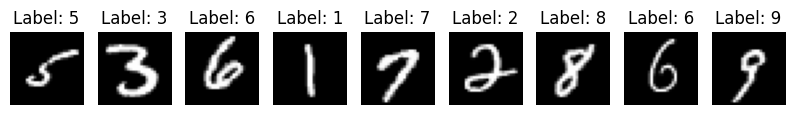

In [5]:
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# Define a transform to convert PIL images to tensors and normalize to [0, 1]
transform = transforms.Compose([transforms.ToTensor()])

# Load the MNIST training and test sets
trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Convert data to NumPy arrays (flatten images from 28x28 to 784)
X_train = trainset.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
y_train = trainset.targets.numpy()

X_test = testset.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
y_test = testset.targets.numpy()

# Function to show images
def show_images(images, labels):
    pixels = images.reshape(-1, 28, 28)
    fig, axs = plt.subplots(ncols=len(images), nrows=1, figsize=(10, 3))
    for i in range(len(images)):
        axs[i].imshow(pixels[i], cmap="gray")
        axs[i].set_title("Label: {}".format(labels[i]))
        axs[i].axis("off")
    plt.show()

# Test the show_images function with first 10 images
show_images(X_train[11:20], y_train[11:20])

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

input_size = 784
output_size = input_size
device = torch.device("cpu")

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Set the number of hidden units
        self.num_hidden = 8
        
        # Define the encoder part of the autoencoder
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 256),  # input size: input_size, output size: 256
            nn.ReLU(),  # apply the ReLU activation function
            nn.Linear(256, self.num_hidden),  # input size: 256, output size: num_hidden
            nn.ReLU(),  # apply the ReLU activation function
        )
        
        # Define the decoder part of the autoencoder
        self.decoder = nn.Sequential(
            nn.Linear(self.num_hidden, 256),  # input size: num_hidden, output size: 256
            nn.ReLU(),  # apply the ReLU activation function
            nn.Linear(256, output_size),  # input size: 256, output size: output_size
            nn.Sigmoid(),  # apply the sigmoid activation function to compress the output to a range of (0, 1)
        )

    def forward(self, x):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Pass the encoded representation through the decoder
        decoded = self.decoder(encoded)
        # Return both the encoded representation and the reconstructed output
        return encoded, decoded
    
    # Convert the training data to PyTorch tensors

"""
# Codes for training autoencoder only
num_epochs = 10
learning_rate = 0.001
X_train = np.array([[1,2], [2,3], [3,1], [4,1], [5,2], [6,2], [7,4], [8,3], [9,8], [10,7]], dtype=np.float32)

X_train = torch.from_numpy(X_train)

# Create the autoencoder model and optimizer
model = AutoEncoder()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Define the loss function
criterion = nn.MSELoss()

# Create a DataLoader to handle batching of the training data
train_loader = torch.utils.data.DataLoader(
    X_train, batch_size=32, shuffle=True
)

# Training loop
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, data in enumerate(train_loader):
        # Get a batch of training data and move it to the device
        data = data.to(device)

        # Forward pass
        encoded, decoded = model(data)

        # Compute the loss and perform backpropagation
        loss = criterion(decoded, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update the running loss
        total_loss += loss.item() * data.size(0)

    # Print the epoch loss
    epoch_loss = total_loss / len(train_loader.dataset)
    print(
        "Epoch {}/{}: loss={:.4f}".format(epoch + 1, num_epochs, epoch_loss)
    )

# Run the trained model on the testing data
encoded, decoded = model(torch.from_numpy(np.array([[1,2]], dtype=np.float32)))
print(encoded)
print(decoded)
"""

'\nnum_epochs = 10\nlearning_rate = 0.001\nX_train = np.array([[1,2], [2,3], [3,1], [4,1], [5,2], [6,2], [7,4], [8,3], [9,8], [10,7]], dtype=np.float32)\n\nX_train = torch.from_numpy(X_train)\n\n# Create the autoencoder model and optimizer\nmodel = AutoEncoder()\noptimizer = optim.Adam(model.parameters(), lr=learning_rate)\n\n# Define the loss function\ncriterion = nn.MSELoss()\n\n# Create a DataLoader to handle batching of the training data\ntrain_loader = torch.utils.data.DataLoader(\n    X_train, batch_size=32, shuffle=True\n)\n\n# Training loop\nfor epoch in range(num_epochs):\n    total_loss = 0.0\n    for batch_idx, data in enumerate(train_loader):\n        # Get a batch of training data and move it to the device\n        data = data.to(device)\n\n        # Forward pass\n        encoded, decoded = model(data)\n\n        # Compute the loss and perform backpropagation\n        loss = criterion(decoded, data)\n        optimizer.zero_grad()\n        loss.backward()\n        optimizer

In [8]:
class VAE(AutoEncoder):
    def __init__(self):
        super().__init__()
        # Add mu and log_var layers for reparameterization
        self.mu = nn.Linear(self.num_hidden, self.num_hidden)
        self.log_var = nn.Linear(self.num_hidden, self.num_hidden)

    def reparameterize(self, mu, log_var):
        # Compute the standard deviation from the log variance
        std = torch.exp(0.5 * log_var)
        # Generate random noise using the same shape as std
        eps = torch.randn_like(std)
        # Return the reparameterized sample
        return mu + eps * std

    def forward(self, x):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Compute the mean and log variance vectors
        mu = self.mu(encoded)
        log_var = self.log_var(encoded)
        # Reparameterize the latent variable
        z = self.reparameterize(mu, log_var)
        # Pass the latent variable through the decoder
        decoded = self.decoder(z)
        # Return the encoded output, decoded output, mean, and log variance
        return encoded, decoded, mu, log_var

    def sample(self, num_samples):
        with torch.no_grad():
            # Generate random noise
            z = torch.randn(num_samples, self.num_hidden).to(device)
            # Pass the noise through the decoder to generate samples
            samples = self.decoder(z)
        # Return the generated samples
        return samples

# Define a loss function that combines binary cross-entropy and Kullback-Leibler divergence
def loss_function(recon_x, x, mu, logvar):
    # Compute the binary cross-entropy loss between the reconstructed output and the input data
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, input_size), reduction="sum")
    # Compute the Kullback-Leibler divergence between the learned latent variable distribution and a standard Gaussian distribution
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # Combine the two losses by adding them together and return the result
    return BCE + KLD

def train_vae(X_train, learning_rate=1e-3, num_epochs=10, batch_size=32):
    # Convert the training data to PyTorch tensors
    X_train = torch.from_numpy(X_train).to(device)

    # Create the autoencoder model and optimizer
    model = VAE()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Define the loss function
    criterion = nn.MSELoss(reduction="sum")

    # Set the device to GPU if available, otherwise use CPU
    model.to(device)

    # Create a DataLoader to handle batching of the training data
    train_loader = torch.utils.data.DataLoader(
        X_train, batch_size=batch_size, shuffle=True
    )

    # Training loop
    for epoch in range(num_epochs):
        total_loss = 0.0
        for batch_idx, data in enumerate(train_loader):
            # Get a batch of training data and move it to the device
            data = data.to(device)

            # Forward pass
            encoded, decoded, mu, log_var = model(data)

            # Compute the loss and perform backpropagation
            KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            loss = criterion(decoded, data) + 3 * KLD
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Update the running loss
            total_loss += loss.item() * data.size(0)

        # Print the epoch loss
        epoch_loss = total_loss / len(train_loader.dataset)
        print(
            "Epoch {}/{}: loss={:.4f}".format(epoch + 1, num_epochs, epoch_loss)
        )

    # Return the trained model
    return model

In [ ]:
#X_train = np.array([[1,2], [2,3], [3,4], [4,5], [5,6], [6,7], [7,8], [8,9], [9,10], [10,11]], dtype=np.float32)
model = train_vae(X_train)

"""
# Run the trained model on the testing data
encoded, decoded, mu, log_var = model(torch.from_numpy(X_train))
print("Encoded:", encoded)
print("Decoded:", decoded)
print("Mu:", mu)
print("Log Variance:", log_var)
"""

Epoch 1/10: loss=1713.4592
Epoch 2/10: loss=1592.8681
Epoch 3/10: loss=1549.7738
Epoch 4/10: loss=1527.3335
Epoch 5/10: loss=1514.4409
Epoch 6/10: loss=1506.8728
Epoch 7/10: loss=1500.6884
Epoch 8/10: loss=1496.9635
Epoch 9/10: loss=1493.2043
Epoch 10/10: loss=1490.1545


Encoded Shape: torch.Size([10, 8])
Decoded Shape: torch.Size([10, 784])
Mu Shape: torch.Size([10, 8])
Log Variance Shape: torch.Size([10, 8])


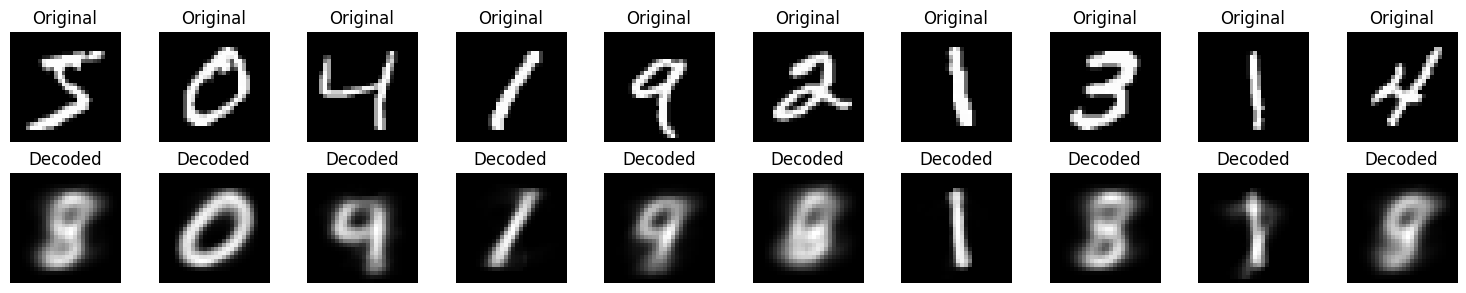

In [26]:
# Convert first 10 samples to torch tensor
X_test_tensor = torch.tensor(X_train[:10], dtype=torch.float32)

# Run the model on test data
model.eval()  # Set to evaluation mode
with torch.no_grad():
    encoded, decoded, mu, log_var = model(X_test_tensor)

# Print results
print("Encoded Shape:", encoded.shape)
print("Decoded Shape:", decoded.shape)
print("Mu Shape:", mu.shape)
print("Log Variance Shape:", log_var.shape)

# Optional: visualize original and reconstructed images
def show_side_by_side(originals, reconstructions, n=10):
    fig, axs = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axs[0, i].imshow(originals[i].reshape(28, 28), cmap="gray")
        axs[0, i].axis("off")
        axs[0, i].set_title("Original")
        axs[1, i].imshow(reconstructions[i].reshape(28, 28), cmap="gray")
        axs[1, i].axis("off")
        axs[1, i].set_title("Decoded")
    plt.tight_layout()
    plt.show()

# Convert tensors to numpy
decoded_np = decoded.cpu().numpy()
original_np = X_test_tensor.numpy()

# Show comparison
show_side_by_side(original_np, decoded_np)

In [ ]:
"""
Condition? Only sex?"
"""


2.0.1
